# Probabilistic Design Optimization Final Project: Trajectory Optimization Under Uncertainty for Autonomous Surface Vessel
> Ivy Mahncke
> Spring 2026

## 1 Executive Summary

In this project, I use optimization methods to find the most efficient sequence of motion control commands for an Autonomous Surface Vessel (ASV) to execute as it navigates to a given waypoint in a disturbance-heavy marine environment. I formulate the scenario as a multi-objective optimization problem where distance to waypoint and energy consumption are objective functions to minimize. I further constrain the problem by designating off-limits areas and defining physical motion constraints for the ASV. I also model uncertainty present in the environment and the ASV's motion to optimize for reliability and robustness metrics. In a deterministic, single-objective model, the optimizer successfully converges on an efficient and physically feasible solution, including in scenarios where heavy environmental disturbances are present. When disturbances are generally assistive, the model utilizes them alongside its control vector to more quickly minimize ASV distance from the final waypoint. When disturbances are generally obstructive, the model still attempts to minimize its objective as quickly as possible, even if reaching the waypoint is physically impossible.

## 2 Background

### 2.1 Problem Context

- Environmental monitoring is difficult and costly for human divers, but it needs to be performed frequently to produce useful data
- ASVs are capable of autonomously exploring and monitoring designated regions without experiencing fatigue
- Marine environments are dynamic and uncertain due to environmental disturbances such as wind and current
- Optimal path-planning is necessary due to limited battery life and availability of field teams
- Makes more sense to optimize control vector because ASV can directly control it, rather than position directly which is a function of control vectors and environmental disturbances

### 2.2 Stakeholders, Rquirements, and Objectives

- Shore Research Team interests:
  - effective data collection that leads to results and actions
  - valuable data that is relevant to ongoing projects
  - consistent and reliable data collection over time
- Field Deployment Team interests:
  - efficient and thorough data collection due to human deployment limits
  - safety of public, wildlife, and ASV during operation
  - no repeats; all necessary data collected in a single deployment
- Marine Wildlife & Ecosystem interests:
  - minimal disruption experienced due to monitoring
  - human aid for environmental health and robustness

- Mission requirements:
  - Efficiency (all waypoints visited)
  - Safety (ASV does not venture into off-limits zones or extend past its limitations)
- Mission objectives:
  - Efficiency (waypoints visited as quickly as possible)
  - Safety (mission uses the least amount of energy possible)

### 2.3 Tenchi Diagram

<img src="./images/final_tenchi.png" width="600">

## 3 Optimization Problem Formulation

### 3.1 Objective Function

The objective function describes the multi-objective minimization of A) cumulative distance from the ASV's position at all times to the waypoint, and B) energy consumed by the ASV at the point of mission completion.

> *NOTE: i can essentially choose to do cumulative distance + energy consumption, OR i can do final distance + time elapsed. i intend to try both methods and just see what worked better, especially in the face of disturbance and uncertainty*

$$min f(u)=E[J_{distance}+J_{energy}]$$

where:

$$J_{distance}=\sum_{k=0}^N||(p_{x,k}-w_x)||_2$$

$$J_{energy}=\sum_{k=0}^{N}\omega_k^2$$

The decision variable driving the optimization is the sequence of control vectors that dictate the ASV's motion in physical space. The control vector contains a linear velocity term and an angular velocity term.

w.r.t.

$$u=[u_0:u_N]$$
$$u_k=(v_k,\omega_k)$$

The optimization is constrained by several factors, including off-limits regions of physical space, limitations on time and energy consumption, and  bounds on control vector values.

s.t.

$$p \notin P_{off-limits}$$

$$k \leq N$$

$$J_{energy}\leq E_{max}$$

$$|v_k|\leq v_{max}$$

$$|\omega_k|\leq \omega_{max}$$

### 3.2 ASV Kinematics

The objective function is minimized by a sequence of control vectors, but the ASV's success is defined by its sequence of positions, which is a related but not identical value. Kinematic equations relate the ASV's position to control vectors as well as environmental disturbances. As such, all variables referenced here represent actual values, rather than values measured or intended by the ASV, unless stated otherwise.

#### 3.2a State Spaces

State spaces describe sets of variables that collectively describe a key attribute about a model. The state spaces below act as a key to relate individual variables and the behaviors they influence together.

The ASV state describes key values about the ASV's position, orientation, and motion in physical space. It is comprised of the ASV's x position, y position, heading, linear velocity, and angular velocity.

*ASV state:*

$$x_k=[p_x, p_y, \theta]$$

The ASV control vector describes the ASV's intention of movement, which is imperfectly executed by motors in the physical world. It is comprised of the ASV's commanded linear velocity (driven by a forward thruster) and angular velocity, (driven by a motorized rudder).

*ASV control:*

$$u_k=(v_k,\omega_k)$$

The environmental disturbance vector describes the environment's physical influence on the ASV's motion, modeled as velocity. It is comprised a magnitude and angle, which can be broken down into an x and y component.

*Environmental disturbance:*

$$d=d_x+d_y=|d|cos(\angle d)+|d|sin(\angle d)$$

#### 3.2b Motion Kinematics

These are the set of equations governing the ASV's state transition after each timestep. These relate the ASV's next state to its current state, control vectors, and active disturbances.

$$p_{x,k+1}^{}=p_{x,k}+(v_kcos(\theta_k)+d_x)*dt$$

$$p_{y,k+1}=p_{y,k}+(v_ksin(\theta_k)+d_y)*dt$$

$$\theta_{k+1}=\omega_{k}*dt$$

### 3.3 Uncertainty

This model considers uncertainty where it is pertinent to the reliability and robustness of the model in the real-world. Uncertainty is present in the model via natural variation in environmental disturbances and noise in motor command execution. Some sources of uncertainty, including waypoint position relative to deployment point and location of any nearby obstacles, would be handled by modules outside of the local planner (by a global planner and an obstacle detection module, respectively). Therefore, those features are considered deterministic within this model. Each source of uncertainty can be characterized by whether its cause is assignable and whether its source is real.

| Source&darr; Cause&rarr; | Chance | Assignable |
| -------- | -------- | ------- |
| **Erroneous** | Motor signal noise | N/A |
| **Real** | Magnitude and angle of disturbance | Relative location of obstacles & waypoint |

>*TODO: Gaussians for now; dig into more accurate modeling later*

>*QUESTION: I threw out variation in exact deployment pt and waypt location because they didn't really inform any modeling decisions or reliability that wasn't taken care of by the kinematics. If it were modelled, it would be better to just model state estimate uncertainty throughout the trajectory. Is this reasonable?*

#### 3.3a Motor Command Execution Noise

> *QUESTION: I couldn't find any examples of people characterizing the BlueRobotics M200 motor online (or really any specific motors. no idea how to get around just making this up???)*
$$v_k^{actual}=v_k^{cmd}+\mathcal{N}(0,0.10)$$
$$\omega_k^{actual}=\omega_k^{cmd}+\mathcal{N}(0,0.10)$$

#### 3.3b Environmental Disturbance Deviation

Wind and current, which together comprise the environmental disturbance velocity, are both highly variable features that depend on extremely local conditions such as temperature, season, water depth, atmospheric patterns, and more. As such, there is not a way to reasonably model environmental disturbance as a distribution in a physically grounded way.

However, we can make a few design choices based on system usage and stakeholder values. For example, the ASV should not operate in any condition where it cannot reliably stay in place for retrieval by its field team. Additionally, the ASV not should have to expend excessive amounts of power to stay in place, which places it at risk of losing power in the field. Both outcomes are unsafe for the ASV and go against the interests of the scenario's stakeholders. As such, this model will only address scenarios in which the disturbance magnitude is reliably (>95%) under the ASV's maximum speed, $3m/s$, and its expected value is equal to one-third of the ASV's maximum speed, $1.0m/s$.

> *QUESTION: how to select distribution shape without just choosing Gaussian and calling it a day? I can calculate all of its characteristics with py-grama later, but I'm stuck on this one...*

$$|d|\sim \mathcal{D}_{magnitude}$$
$$CDF_{\mathcal{D}_{m}}(x = 3.0) = 0.95$$
$$E[\mathcal{D}_{m}] = 1.0$$

Unlike magnitude, angle of net environmental disturbance cannot obstruct the ASV's motion to the point of inoperability. As such, this model will consider all potential headings equally likely.

$$\angle d\sim\mathcal{U}(-\pi,\pi)$$

Although the magnitude and angle of net environmental disturbance can vary on the order of minutes, the scope of this model, as a local planner, generally does not include paths that are over a minute. Therefore, the model assumes that disturbance magnitude and angle is constant once sampled for each scenario.

> *QUESTION: i could make both values vary slightly from timestep to timestep... could be more realistic but if i can't ground it in any numbers then... why?*

#### 3.3c Obstacle & Waypoint Locations

While both of these situation-specific points could potentially be modeled as anomolous uncertainty, the knowledge that the local planner would have of each comes from other modules in the autonomy stack. For example, the location of the local planner's next waypoint is chosen by the global planner, meaning that in a full-stack context, the local planner could expect to know its location concretely rather than probabilistically model it. As for obstacles, the local planner's awareness of any obstacles would also come from an external autonomy module; specifically, some type of sensor-based obstacle detector. In this case, the precise location of a given obstacle is likely somewhat obscured by the noise of the sensors used to find it. However, since our model is intended to be agnostic to other modules in a hypothetical autonomy stack, it makes more sense to assume that the location of any obstacle is deterministic rather than characterize its hypothetical uncertainty poorly.

## 4 Model Implementation

### 4.1 Imports, Constants, Parameters, Decision Variables

In [17]:
# TODO: implement energy calcs in a gounded way
# TODO: add uncertainty to parameters
# TODO: add uncertainty to disturbance forces
# TODO: add multi-objective optimization
# TODO: add off-limits position set - bounds
# TODO: add off-limits position set - obstacles

import grama as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# constants
DT = 0.1 # sec
V_MAX = 3.0 # m/s
W_MAX = 3.0 # rad/s
disturbance = (0.2,math.pi/2) # m/s, rad
d_x = disturbance[0]*math.cos(disturbance[1]) # m/s
d_y = disturbance[0]*math.sin(disturbance[1]) # m/s
tol = 1e-6

# parameters
total_time = 15 # sec
timesteps = int(total_time/DT)
deployment_state = (0.0, 0.0, 0.0) # x, y, theta
waypt = (4.0, 5.0) # x, y


# grama variable vectors
controls = [f"w{int(k/2)}" if k % 2 == 0 else f"v{int(k/2)}" for k in range(timesteps*2)] # lin vel, ang vel
objectives = ["J", "T", "R", "D", "L"] # all possible objective functions
obj = objectives[2] # selected objective function
states = [f"x{k}" for k in range(timesteps)] # all state variables

### 4.2 ASV Kinematics Implementation

In [18]:
def state_transition(init_state: tuple[float,float,float],control_vec: pd.Series,):
    """
    Helper function to perform state transitions from an initial state using a control vector.
    """
    # grab initial state
    states = [init_state]

    # grab sequential control vectors
    lin_vels = [control_vec[f"v{k}"] for k in range(timesteps)]
    ang_vels = [control_vec[f"w{k}"] for k in range(timesteps)]

    # iterate through control vector
    for vk, wk in zip(lin_vels, ang_vels):
        # state variables
        xk, yk, thk = states[-1]

        # kinematics
        xk1 = xk + DT*vk*math.cos(thk) + d_x*DT
        yk1 = yk + DT*vk*math.sin(thk) + d_y*DT
        thk1 = thk + DT*wk
        thk1 = np.arctan2(np.sin(thk1), np.cos(thk1)) # wrap to [-pi, pi]

        # iterate state
        states.append((xk1, yk1, thk1))
    
    # return final state sequence
    return states

### 4.3 Various Objective Functions I'm Playing With

In [19]:
def T_time_elapsed(control_vec: pd.Series):
    """
    Vectorized function to calculate the T (elapsed time before reaching waypoint) column of a scenario row.
    """
    # perform state transition
    state_sequence = state_transition(deployment_state,control_vec)

    for k, s in enumerate(state_sequence):
        # state variables
        xk, yk, _ = s

        # add to sum distance
        if np.sqrt((xk-waypt[0])**2 + (yk-waypt[1])**2) < tol:
            return k
        
    # no convergence
    return len(state_sequence) - 1

def R_final_distance(control_vec: pd.Series):
    """
    Vectorized function to calculate the R (final distance from waypoint) column of a scenario row.
    """
    # perform state transition
    state_sequence = state_transition(deployment_state,control_vec)
    
    # return raw distance from final state to waypoint
    xf, yf, _ = state_sequence[-1]
    return np.sqrt((xf-waypt[0])**2 + (yf-waypt[1])**2)

def D_total_distance(control_vec):
    """
    Vectorized function to calculate the D (total distance from waypoint across time) column of a scenario row.
    """
    # sum distance
    sum_distance = 0

    # perform state transition
    state_sequence = state_transition(deployment_state,control_vec)

    # iterate through state sequence
    for s in state_sequence:
        # state variables
        xk, yk, _ = s

        # add to sum distance
        sum_distance += np.sqrt((xk-waypt[0])**2 + (yk-waypt[1])**2)
    
    # return raw distance from state to waypoint
    return sum_distance

def L_weighted_distance(control_vec):
    """
    Vectorized function to calculate the L (weighted total distance from waypoint across time) column of a scenario row.
    """
    # sum distance
    sum_distance = 0

    # perform state transition
    state_sequence = state_transition(deployment_state,control_vec)

    # iterate through state sequence
    for k, s in enumerate(state_sequence):
        # state variables
        xk, yk, _ = s

        # weight
        w = k/timesteps

        # add to sum distance
        sum_distance += w*np.sqrt((xk-waypt[0])**2 + (yk-waypt[1])**2)
    
    # return raw distance from state to waypoint
    return sum_distance

# TODO: model energy consumption in a way that is not completely baseless
def J_final_energy(control_vec):
    """
    Vectorized function to calculate the J (final energy) column of a scenario row.
    """
    # relative energy consumption
    relative_energy = 0.0

    # iterate through control vector
    for wk in control_vec:
        relative_energy += wk**2
    
    # return total relative energy
    return relative_energy

### 4.4 Optimizable ASV Motion Model (with constraints!)

In [20]:
def model_trajectory(df_in: pd.DataFrame):
    """
    DataFrame-based method of extracting objective function values from a given control input sequence.

    Args:
        df_in: A DataFrame in which each column represents a linear or angular velocity at a specific timestep.

    Returns:
        df_out: A DataFrame in which each column represents an objective function value.
    """
    # establish the out dataframe
    df_out = pd.DataFrame()
    
    # establish vectorized functions for objectives
    df_out["R"] = df_in.apply(R_final_distance,axis="columns")
    df_out["D"] = df_in.apply(D_total_distance,axis="columns")
    df_out["L"] = df_in.apply(L_weighted_distance,axis="columns")
    df_out["J"] = df_in.apply(J_final_energy,axis="columns")
    df_out["T"] = df_in.apply(T_time_elapsed,axis="columns")

    # return
    return df_out

# define model
md_asv = (
    # initial model
    gr.Model("ASV Motion Kinematics")
    # state transition kinematics
    >> gr.cp_vec_function(
        fun=model_trajectory,
        var=controls,
        out=objectives,
    )
    # constrain linear velocity commands
    >> gr.cp_bounds(
        **{f"v{k}": (-0.0, +V_MAX) for k in range(timesteps)}
    )
    # constrain angular velocity commands
    >> gr.cp_bounds(
        **{f"w{k}": (-W_MAX, +W_MAX) for k in range(timesteps)}
    )
)

md_asv.printpretty()

model: ASV Motion Kinematics

  inputs:
    var_det:
      w68: [-3.0, 3.0]
      v56: [-0.0, 3.0]
      w22: [-3.0, 3.0]
      v84: [-0.0, 3.0]
      v106: [-0.0, 3.0]
      v111: [-0.0, 3.0]
      w114: [-3.0, 3.0]
      v146: [-0.0, 3.0]
      w18: [-3.0, 3.0]
      w28: [-3.0, 3.0]
      w126: [-3.0, 3.0]
      v59: [-0.0, 3.0]
      w58: [-3.0, 3.0]
      w115: [-3.0, 3.0]
      w74: [-3.0, 3.0]
      v94: [-0.0, 3.0]
      w19: [-3.0, 3.0]
      w17: [-3.0, 3.0]
      w91: [-3.0, 3.0]
      v139: [-0.0, 3.0]
      v134: [-0.0, 3.0]
      w20: [-3.0, 3.0]
      v97: [-0.0, 3.0]
      v79: [-0.0, 3.0]
      v30: [-0.0, 3.0]
      v40: [-0.0, 3.0]
      v12: [-0.0, 3.0]
      w90: [-3.0, 3.0]
      w83: [-3.0, 3.0]
      v108: [-0.0, 3.0]
      w129: [-3.0, 3.0]
      v131: [-0.0, 3.0]
      w1: [-3.0, 3.0]
      v145: [-0.0, 3.0]
      v88: [-0.0, 3.0]
      v10: [-0.0, 3.0]
      w147: [-3.0, 3.0]
      v4: [-0.0, 3.0]
      v114: [-0.0, 3.0]
      v101: [-0.0, 3.0]
      w73: [-3

### 4.5 Single-Objective Optimization

In [21]:
df_test: pd.DataFrame = (
    md_asv
    >> gr.ev_min(
        out_min=obj,
        n_restart=1,
    )
)

Estimated runtime: 0.0000 sec


/home/ivymahncke/miniconda3/envs/pdo/lib/python3.9/site-packages/grama/dataframe.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/home/ivymahncke/miniconda3/envs/pdo/lib/python3.9/site-packages/grama/dataframe.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/home/ivymahncke/miniconda3/envs/pdo/lib/python3.9/site-packages/grama/dataframe.py:81: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

this code let's you pop the best few runs after using `n_restarts>=1`!

In [22]:
pop_count = 1
optimal_run = []
control_opt = []
opt_val = []
for i in range(pop_count):
    optimal_run.append(df_test.loc[df_test[obj].idxmin()])
    control_opt.append(optimal_run[-1][controls])
    opt_val.append(round(optimal_run[-1][obj],3))

## 5 Optimization Results

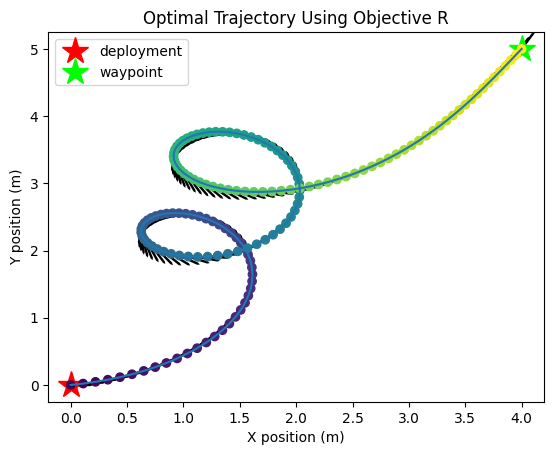

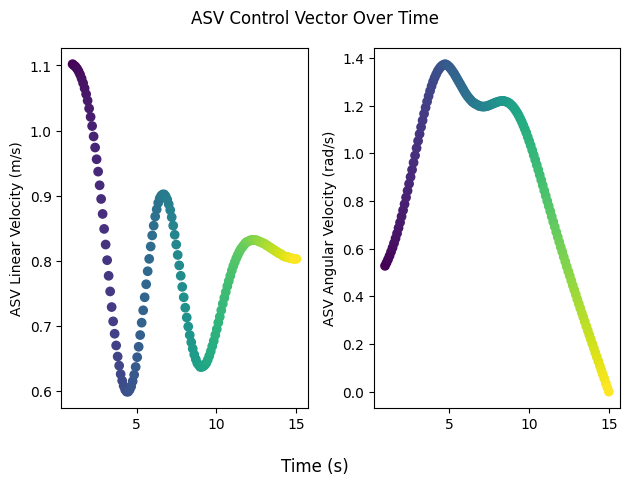

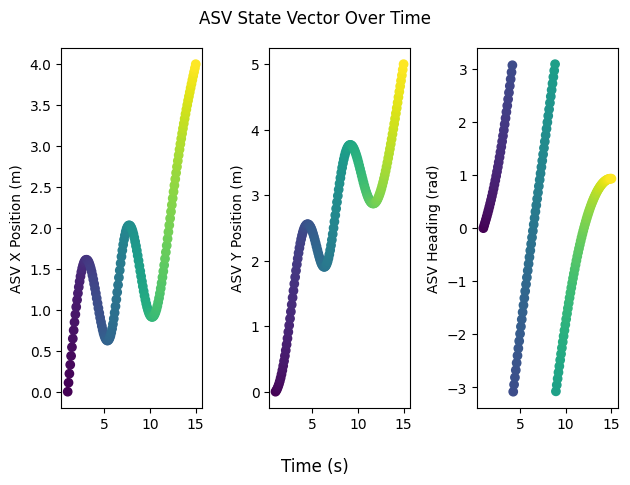

In [23]:
def plot_trajectory(control_vec,deployment_state,label,):
    """
    Given an initial state and control vector, plot the generated trajectory.
    """
    # state transition
    state_sequence = state_transition(deployment_state,control_vec)
    x_vec = [s[0] for s in state_sequence]
    y_vec = [s[1] for s in state_sequence]
    th_vec = [s[2] for s in state_sequence]


    # plot
    plt.plot(x_vec, y_vec,label=label) # line
    plt.scatter(x_vec, y_vec,c=np.linspace(0, 1, len(x_vec))) # dots
    plt.quiver(x_vec, y_vec, np.cos(th_vec), np.sin(th_vec),headwidth=1,headlength=1,zorder=0)# headings


def plot_control_vector(control_vec,sharex=True, r=3):
    # grab sequential control vectors
    lin_vels = [round(control_vec[f"v{k}"],r) for k in range(timesteps)]
    ang_vels = [round(control_vec[f"w{k}"],r) for k in range(timesteps)]
    tspan = np.linspace(1,total_time,timesteps)

    # set up plotspace
    fig, (ax1, ax2) = plt.subplots(1,2)

    # plot control vectors
    ax1.scatter(tspan,lin_vels,c=np.linspace(0, 1, len(tspan)))
    ax1.set_ylabel("ASV Linear Velocity (m/s)")
    ax2.scatter(tspan,ang_vels,c=np.linspace(0, 1, len(tspan)))
    ax2.set_ylabel("ASV Angular Velocity (rad/s)")

    # layout
    fig.supxlabel("Time (s)")
    fig.suptitle("ASV Control Vector Over Time")
    fig.tight_layout()

def plot_state_vector(control_vec,sharex=True,r=3):
    # grab state sequence
    state_sequence = state_transition(deployment_state,control_vec)
    x_vec = [round(s[0],r) for s in state_sequence]
    y_vec = [round(s[1],r) for s in state_sequence]
    th_vec = [round(s[2],r) for s in state_sequence]
    
    # timespan
    tspan = np.linspace(1,total_time,timesteps+1)

    # set up plotspace
    fig, (ax1, ax2, ax3) = plt.subplots(1,3)

    # plot control vectors
    ax1.scatter(tspan,x_vec,c=np.linspace(0, 1, len(tspan)))
    ax1.set_ylabel("ASV X Position (m)")
    ax2.scatter(tspan,y_vec,c=np.linspace(0, 1, len(tspan)))
    ax2.set_ylabel("ASV Y Position (m)")
    ax3.scatter(tspan,th_vec,c=np.linspace(0, 1, len(tspan)))
    ax3.set_ylabel("ASV Heading (rad)")

    # layout
    fig.supxlabel("Time (s)")
    fig.suptitle("ASV State Vector Over Time")
    fig.tight_layout()

# map
plt.plot(deployment_state[0],deployment_state[1],"*",markersize=20,label="deployment",color="red",zorder=1,)
plt.plot(waypt[0],waypt[1],"*",markersize=20,label="waypoint",color="lime",zorder=1,)
for vec, opt in zip(control_opt, opt_val):
    plot_trajectory(
        vec,
        deployment_state,
        # f"{obj}={round(opt,2)}",
        None,
    )
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title(f"Optimal Trajectory Using Objective {obj}")
plt.legend(loc="upper left")
plt.show()

plot_control_vector(control_opt[-1])
plt.show()

plot_state_vector(control_opt[-1])
plt.show()

# 6 Results of Significance, Conclusion, Future Work